In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import math

In [100]:
#2.1 Collect the Data--------------------------------
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [101]:
#4

shape = df.shape
print("Number of Columns: ", shape[1])   
print("Number of Rows: ", shape[0])
print("Column names:", df.columns)

Number of Columns:  6
Number of Rows:  100
Column names: Index(['x', 'y_noise_1', 'y_noise_2', 'y_noise_3', 'y_noise_4', 'y_noise_5'], dtype='object')


In [7]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [8]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


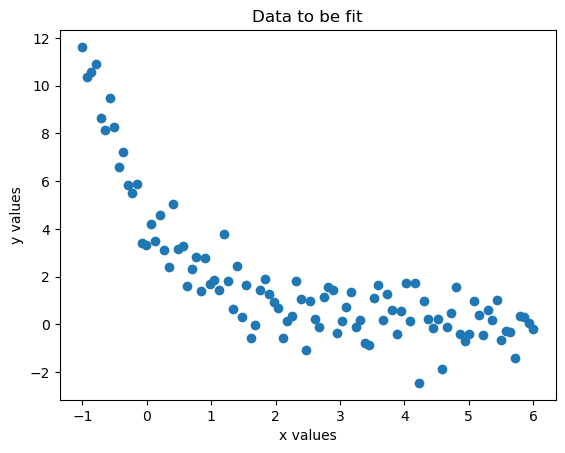

In [104]:
#5. Plot the x vs. y_noise_1

x = df.loc[:, 'x']
y_noise_1 = df.loc[:, 'y_noise_1']
y_noise_2 = df.loc[:, 'y_noise_2']
y_noise_3 = df.loc[:, 'y_noise_3']
y_noise_4 = df.loc[:, 'y_noise_4']
y_noise_5 = df.loc[:, 'y_noise_5']

plt.title('Data to be fit')
plt.xlabel('x values')
plt.ylabel('y values')


plt.scatter(x, y_noise_1,)

plt.show()

In [103]:
#2.2.1

def model(x, A, k):
    return A * np.exp(-k * x)
#2.2.2
p0 = [1,1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)
#3
A_fit, k_fit = popt
#4
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

Fit: y = 4.71 * e^(-0.92 * x)


In [105]:
#5
residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

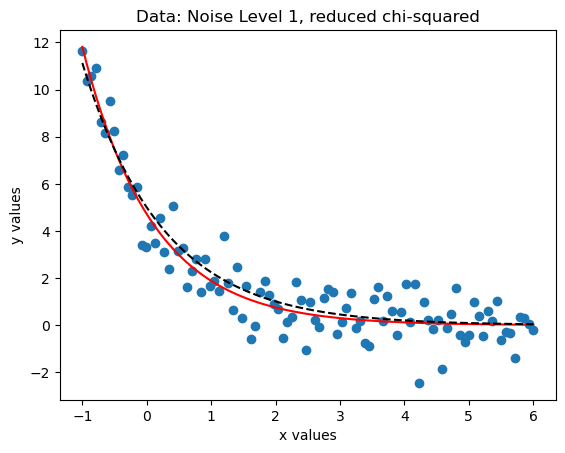

In [106]:
#6
plt.title('Data: Noise Level 1, reduced chi-squared')
plt.xlabel('x values')
plt.ylabel('y values')
plt.scatter(x, y_noise_1,)
plt.plot(x, model(x, A_fit, k_fit), color= "red")
plt.plot(x, model(x, 5, 0.8), color= "black", linestyle = "--")
plt.show()


In [107]:
#2.3 Compare Different Noise Levels----------------
#1
def fit_model(x, y):
    p0 = [1,1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof
    best_fit = f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)"
    return popt, chi2_reduced, best_fit

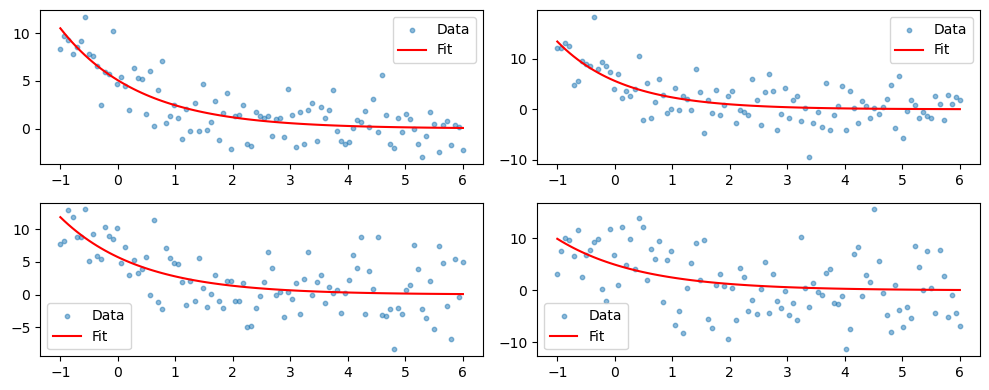

In [108]:
#2
fig, axes = plt.subplots(2, 2, figsize=(10, 4))
axes_flat = axes.flatten()

dataset_string = [y_noise_2, y_noise_3, y_noise_4, y_noise_5]
#3
for i, y_data in enumerate(dataset_string):
    popt, chi2_red, fit_label = fit_model(x, y_data)
    A_f, k_f = popt
    
    axes_flat[i].scatter(x, y_data, s=10, label='Data', alpha=0.5)
    
    x_smooth = np.linspace(x.min(), x.max(), 100)
    axes_flat[i].plot(x_smooth, model(x_smooth, A_f, k_f), 'r', label='Fit')
    
    axes_flat[i].legend()

plt.tight_layout()
plt.show()


In [ ]:
#4. As the Noise Level is increased, the lines become further apart as the red line gets more values that it wants to account for and thus skews the value
#the reduced chi-squared decreases because there is more values that introduce mroe randomness and variability.

In [97]:
#2.4 Save Your Results---------------
results = []
noise_datasets = [y_noise_1, y_noise_2, y_noise_3, y_noise_4, y_noise_5]
noise_labels = [1, 2, 3, 4, 5]

for noise, y_data in zip(noise_labels, a_datasets):
    popt, chi2_red, _ = fit_model(x, y_data)
    
    results.append({
        'Noise level': noise,
        'A fit': popt[0],
        'k fit': popt[1],
        'Reduced chi-squared': chi2_red
    })

new_df = pd.DataFrame(results_list)
new_df

,Noise level,A fit,k fit,Reduced chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [99]:
new_df.to_csv("noisy_parameters.csv", index = False)